Nom : Khadijetou Mohamed abe

Filière : GLCC


# 1. CODE SCRATCH

In [3]:
import numpy as np

def Parametres_NaiveBayes(X, y):
    # """
    # Cette fonction calcule les statistiques nécessaires pour le modèle Naive Bayes.
    # On a besoin de la moyenne, la variance et la probabilité a priori pour chaque classe.
    # """
    # Récupérer les classes uniques (0, 1, 2)
    classes = np.unique(y)
    # Nombre de caractéristiques (colonnes de X)
    n_features = X.shape[1]
    
    # Dictionnaires pour stocker les paramètres par classe
    moyens = {}
    variances = {}
    priors = {}

    for c in classes:
        # On sélectionne seulement les lignes qui appartiennent à la classe c
        X_c = X[y == c]
        # Calcul de la moyenne pour chaque feature de cette classe
        moyens[c] = np.mean(X_c, axis=0)
        # Calcul de la variance pour chaque feature (on ajoute 10**-6 pour éviter la division par 0)
        variances[c] = np.var(X_c, axis=0) + 10**-6
        # Calcul de la probabilité a priori P(y) = (nombre d'exemples classe c) / (total)
        priors[c] = X_c.shape[0] / len(y)
        
    return classes, moyens, variances, priors

def predict_NaiveBayes(X, classes, moyens, variances, priors):
    # """
    # Prédit la classe pour chaque ligne de X en utilisant la règle du Maximum A Posteriori (MAP)
    # y_predit=argmaxP(y)*produit(P(xi|y)).
    # On utilise la somme des LOGS pour éviter que les petites probabilités ne deviennent zéro.
    # => y_predit=argmax[(log P(y) + somme(log P(xi|y)) ).
    # """
    predictions = []
    
    # Pour chaque ligne de données 
    for x in X:
        scores_classes = []
        for c in classes:
            # Récupérer les paramètres de la classe
            # la moyenne
            mean = moyens[c]
            # la variance
            var = variances[c]
            # log P(y)
            prior = np.log(priors[c])
            
            # Formule de la loi normale (Gauss) pour la vraisemblance P(xi | y) = (1/sqrt(2*pi*var))) np.exp**( - (x-mean)^2 / (2*var)) 
            # On calcule tout en LOG : log(1/sqrt(2*pi*var)) - (x-mean)^2 / (2*var)
            vraisemblance_par_feature = -0.5 * np.log(2 * np.pi * var) - 0.5 * ((x - mean)**2 / var)
            
            # Somme des logs des vraisemblances pour toutes les features
            vraisemblance_totale = np.sum(vraisemblance_par_feature)
            
            # Score final (Posterior) = log(Prior) + log(Likelihood)
            score = prior + vraisemblance_totale
            scores_classes.append(score)
            
        # On prend l'indice du score maximum (la classe la plus probable)
        classe_predite = classes[np.argmax(scores_classes)]
        predictions.append(classe_predite)
        
    return np.array(predictions)


## a. DATASET

In [4]:
# Création de points pour 3 groupes différents
np.random.seed(42)
# Groupe 0 (Centré autour de [2, 4])
X0 = np.random.randn(20, 2) + np.array([2, 4])
# Groupe 1 (Centré autour de [4, 5])
X1 = np.random.randn(20, 2) + np.array([4, 5])
# Groupe 2 (Centré autour de [3, 2])
X2 = np.random.randn(20, 2) + np.array([3, 2])

# Fusion des données en une seule matrice X_data
X_data = np.vstack((X0, X1, X2))
# Création des étiquettes (0, 1, 2)
y_data = np.array([0]*20 + [1]*20 + [2]*20)

## b. Exécution du code scratch

In [5]:
# Entraînement : calcul des moyennes et variances
classes, moyens, variances, priors = Parametres_NaiveBayes(X_data, y_data)
# Prédiction sur nos données
predictions_scratch = predict_NaiveBayes(X_data, classes, moyens, variances, priors)

## c. Code sklearn

In [6]:
from sklearn.naive_bayes import GaussianNB
# Initialisation du modèle Gaussian Naive Bayes
modele_sklearn = GaussianNB()
# Entraînement avec fit
modele_sklearn.fit(X_data, y_data)
# Prédiction avec predict
predictions_sklearn = modele_sklearn.predict(X_data)


## d. Comparaison et graphiques (scratch/sklearn)


--- Comparaison des moyennes calculées ---
Moyennes Scratch (Classe 0) : [1.82389699 3.73882933]
Moyennes Sklearn (Classe 0) : [1.82389699 3.73882933]
Précision Scratch : 78.33333333333333 %
Précision Sklearn : 78.33333333333333 %


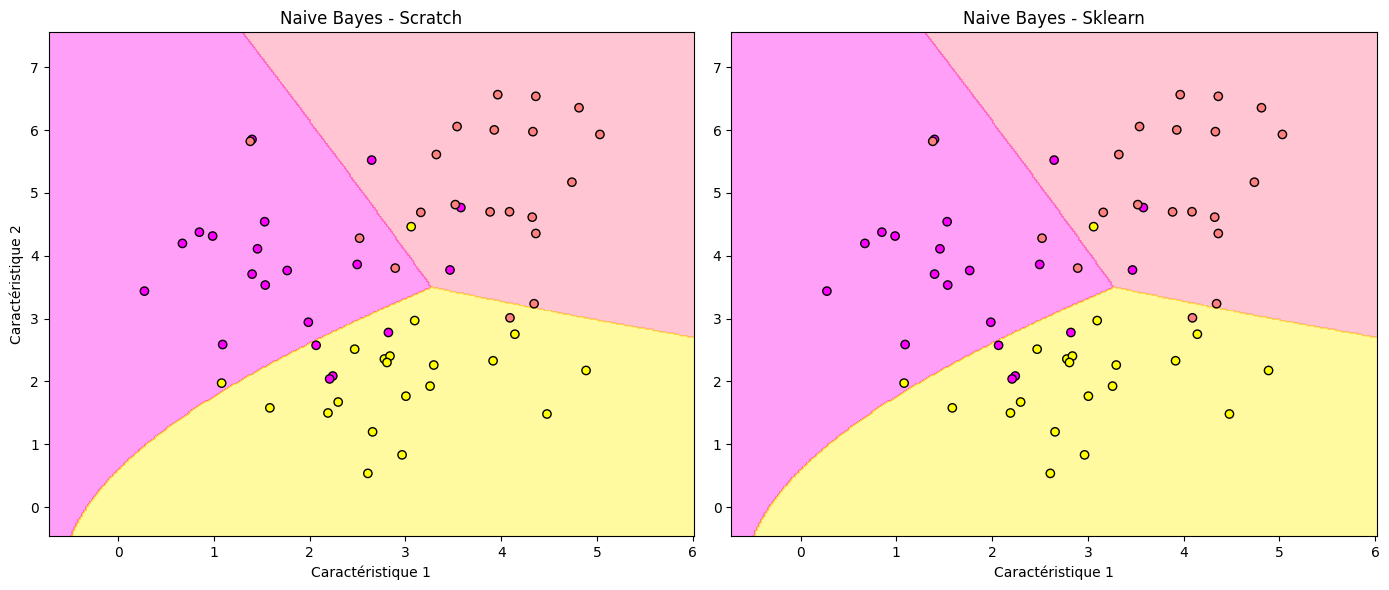

In [13]:
# Conclusion finale de comparaison
print("\n--- Comparaison des moyennes calculées ---")
print("Moyennes Scratch (Classe 0) :", moyens[0])
print("Moyennes Sklearn (Classe 0) :", modele_sklearn.theta_[0])

print("Précision Scratch :", np.mean(predictions_scratch == y_data) * 100, "%")
print("Précision Sklearn :", np.mean(predictions_sklearn == y_data) * 100, "%")

import matplotlib.pyplot as plt

# Préparation de la visualisation des frontières de décision
h = .02 # pas de la grille
x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Points de la grille pour la prédiction
points_grille = np.c_[xx.ravel(), yy.ravel()]

# Prédiction Scratch sur la grille
Z_scratch = predict_NaiveBayes(points_grille, classes, moyens, variances, priors)
Z_scratch = Z_scratch.reshape(xx.shape)

# Prédiction Sklearn sur la grille
Z_sklearn = modele_sklearn.predict(points_grille)
Z_sklearn = Z_sklearn.reshape(xx.shape)

# Affichage des graphiques
plt.figure(figsize=(14, 6))

# Sous-graphique 1 : Scratch
plt.subplot(1, 2, 1)
# Colorer les zones de décision
plt.contourf(xx, yy, Z_scratch, alpha=0.4, cmap='spring')
# Afficher les points réels
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolors='k', cmap='spring')
plt.title("Naive Bayes - Scratch")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")

# Sous-graphique 2 : Sklearn
plt.subplot(1, 2, 2)
# Colorer les zones de décision
plt.contourf(xx, yy, Z_sklearn, alpha=0.4, cmap='spring')
# Afficher les points réels
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolors='k', cmap='spring')
plt.title("Naive Bayes - Sklearn")
plt.xlabel("Caractéristique 1")

plt.tight_layout()
plt.show()